# Fine tunning VGG16.



In [3]:
# Intalación de dependencias.
!pip -q install kaggle

In [5]:
# Damos acceso al API token de kaggle.
!mkdir -p /root/.config/kaggle
!cp "/content/drive/MyDrive/Plant-pathology/kaggle.json" /root/.config/kaggle/kaggle.json
!chmod 600 /root/.config/kaggle/kaggle.json

In [6]:
!kaggle competitions download -c plant-pathology-2020-fgvc7

 97% 754M/779M [00:08<00:00, 186MB/s]
100% 779M/779M [00:08<00:00, 97.4MB/s]


In [8]:
# Descomprimimos la base de datos en el drive.
data_dest_folder = "/content/drive/MyDrive/Plant-pathology/data"
zip_file_path = "/content/plant-pathology-2020-fgvc7.zip"
!mkdir -p "{data_dest_folder}"
!unzip -q "{zip_file_path}" -d "{data_dest_folder}"

In [10]:
# Impotamos librerías a utilizar.
import tensorflow as tf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import wandb
from wandb.integration.keras import WandbCallback
from wandb.integration.keras import WandbMetricsLogger

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical, image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam, AdamW, RMSprop
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight

In [2]:
# Importamos los datos del drive de colab.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
os.environ["WANDB_API_KEY"] = "0df13b0c5c253813bd9eb5bfff98fdfb82fa37d0"

In [23]:
wandb.login(key=os.getenv("WANDB_API_KEY"))

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: emilio-soto (emilio-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [13]:
# Ordenamos los datos.
data_path = "/content/drive/MyDrive/Plant-pathology/data"
image_dir = f"{data_path}/images"
csv_path = f"{data_path}/train.csv"

# Visualizamos.
df = pd.read_csv(csv_path)
df.head(8)

,image_id,healthy,multiple_diseases,rust,scab
0,Train_0,0,0,0,1
1,Train_1,0,1,0,0
2,Train_2,1,0,0,0
3,Train_3,0,0,1,0
4,Train_4,1,0,0,0
5,Train_5,1,0,0,0
6,Train_6,0,1,0,0
7,Train_7,0,0,0,1


In [14]:
# Convertimos a one hot encoding en una sola columna.
label_columns = ['healthy', 'multiple_diseases', 'rust', 'scab']
df['label'] = df[label_columns].idxmax(axis=1)

In [15]:
# Revisamos las imágenes por clase.
print("Conteo de imágenes por clase:")
print(df['label'].value_counts())

Conteo de imágenes por clase:
label
rust                 622
scab                 592
healthy              516
multiple_diseases     91
Name: count, dtype: int64


In [16]:
# Agregamos la extensión .jpg a las imagenes.
if not df['image_id'].str.contains('.jpg').any():
    print("Añadimos extensión .jpg a 'image_id'...")
    df['image_id'] = df['image_id'] + '.jpg'
else:
    print("'image_id' ya tiene la extensión .jpg.")

Añadimos extensión .jpg a 'image_id'...


In [17]:
# División de datos.
# Separamos el test.
main_df, test_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])

# El resto lo separamos entre entrenamiento y validación.
train_df, val_df = train_test_split(main_df, test_size=0.20, random_state=42, stratify=main_df['label'])

In [34]:
# Definimos el tamaño de las imagenes y el tamaño del batch.
IMG_SIZE = (180, 180)
BATCH_SIZE = 32
NUM_CLASSES = 4

# Creamos los generadores.
train_datagen_augmented = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest')

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Creamos los datasets.
train_dataset = train_datagen_augmented.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col='image_id',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42)

validation_dataset = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_dir,
    x_col='image_id',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False)

test_dataset = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=image_dir,
    x_col='image_id',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False)

Found 1019 validated image filenames belonging to 4 classes.
Found 255 validated image filenames belonging to 4 classes.
Found 547 validated image filenames belonging to 4 classes.


In [36]:
# Cargamos el modelo.
MODEL_PATH = "/content/drive/MyDrive/Plant-pathology/VGG16.keras"
model = load_model(MODEL_PATH)

In [37]:
# Evaluamos el modelo.
validation_dataset.reset()

print("Evaluando el modelo en los datos de validación.")
results = model.evaluate(validation_dataset)

print("\n" + "---" * 10)
print(f"Resultados de la Evaluación (VGG16 - Fase 1).")
print(f"Pérdida (Loss) de Validación:   {results[0]:.4f}")
print(f"Precisión (Accuracy) de Validación: {results[1]:.4f}")
print("---" * 10 + "\n")

Evaluando el modelo en los datos de validación.
8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.5856 - loss: 1.0423

------------------------------
Resultados de la Evaluación (VGG16 - Fase 1).
Pérdida (Loss) de Validación:   1.0299
Precisión (Accuracy) de Validación: 0.5922
------------------------------



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 940ms/step


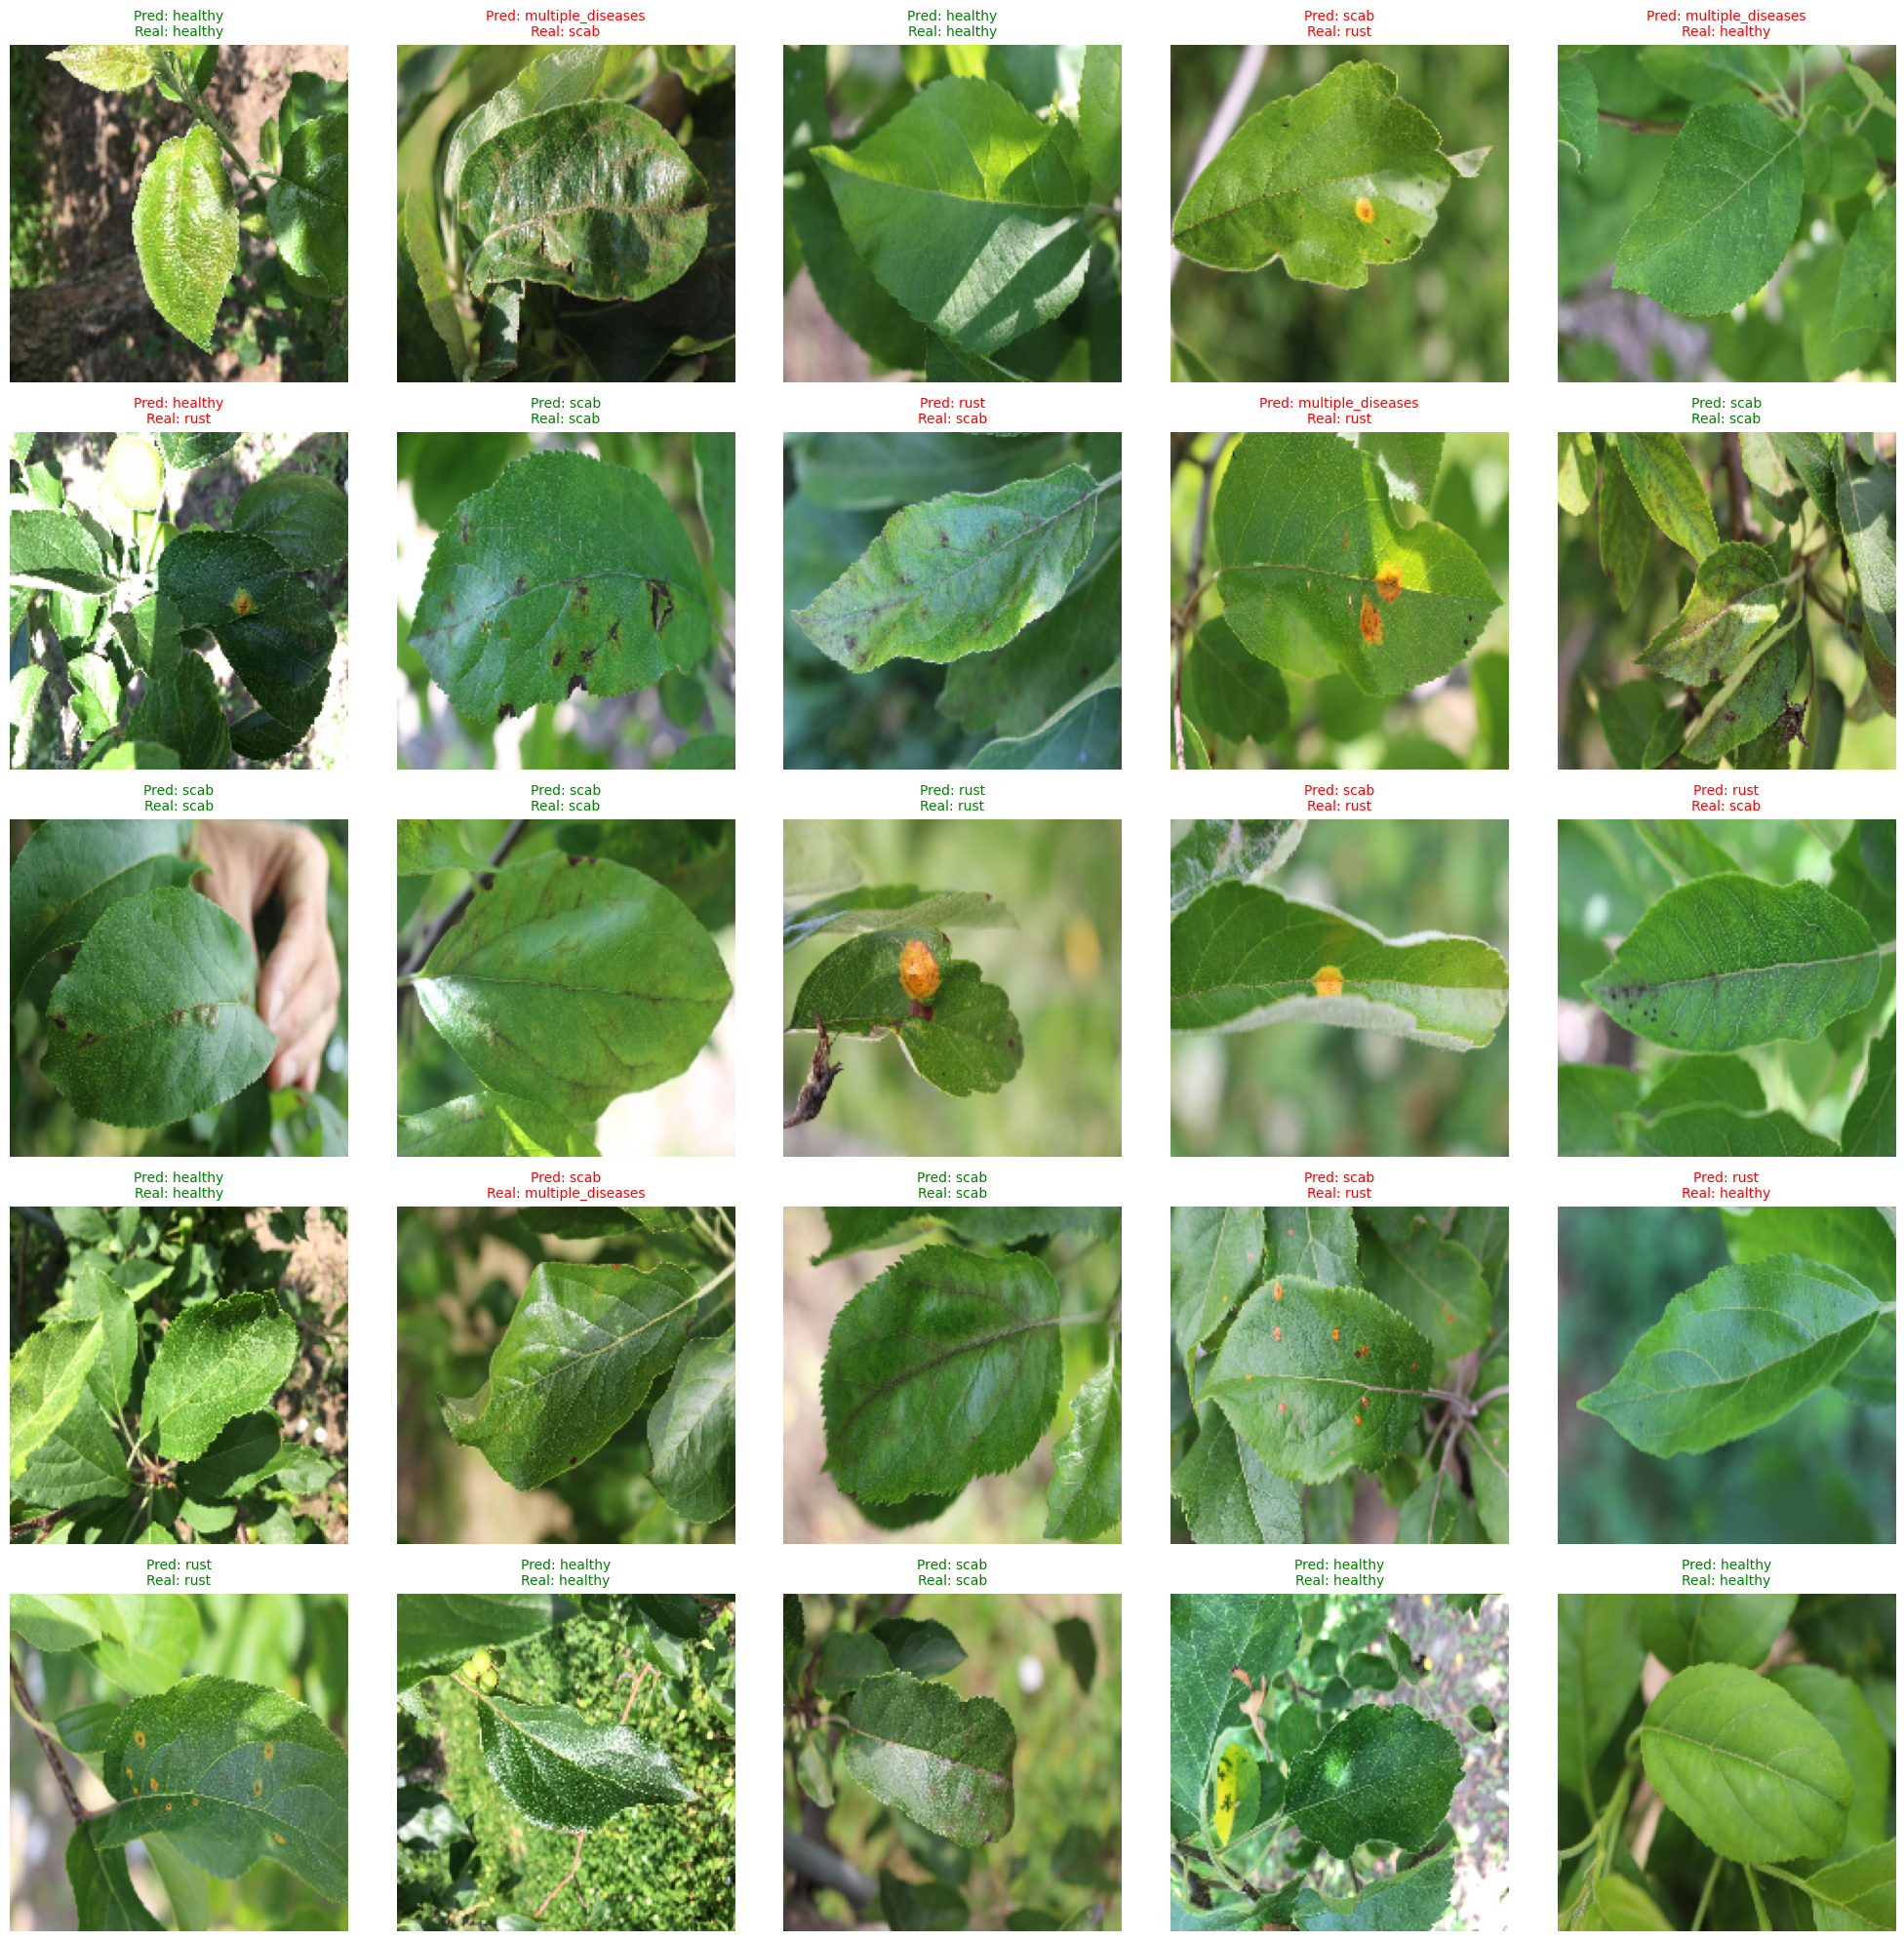

In [39]:
# Reiniciamos el generador de validación para obtener el primer batch.
validation_dataset.reset()
image_batch, label_batch = next(validation_dataset)

# Obtenemos las predicciones para ese batch.
predictions = model.predict(image_batch)

# Convertimos las predicciones (softmax) y etiquetas (one-hot) a índices.
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(label_batch, axis=1)

# Creamos un diccionario para mapear índices a nombres de clases.
class_names = {v: k for k, v in validation_dataset.class_indices.items()}

# Graficamos.
plt.figure(figsize=(20, 20))
n_images = min(25, BATCH_SIZE)
for i in range(n_images):
    plt.subplot(5, 5, i + 1)

    # Las imágenes del generador están en formato 0-1, plt.imshow las maneja bien.
    plt.imshow(image_batch[i])

    # Obtenemos los nombres de las clases.
    pred_name = class_names[predicted_labels[i]]
    true_name = class_names[true_labels[i]]

    color = 'green' if pred_name == true_name else 'red'
    plt.title(f"Pred: {pred_name}\nReal: {true_name}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [40]:
# Configuramos.
config_ft = {
    "learning_rate": 1e-6,
    "architecture": "VGG16_FULL (Fine-Tuned)",
    "batch_size": BATCH_SIZE,
    "img_size": IMG_SIZE,
    "optimizer": "Adam"}

# Iniciamos wandb.
wandb.init(
    project="Plant-Pathology-CNN",
    name="VGG16-FineTuning",
    config=config_ft,
    reinit=True)

# Descongelamos.
model.trainable = True

# Reecompilamos.
model.compile(
    optimizer=Adam(learning_rate=config_ft["learning_rate"]),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [41]:
callbacks_ft = [
    WandbMetricsLogger(log_freq='epoch'),
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1),
    ModelCheckpoint(
        filepath='final_model_vgg_ft.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1)]
# Entrenamos.
history_ft = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=40,
    callbacks=callbacks_ft)
wandb.finish()

Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6319 - loss: 0.9489
Epoch 1: val_accuracy improved from -inf to 0.59216, saving model to final_model_vgg_ft.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.6315 - loss: 0.9496 - val_accuracy: 0.5922 - val_loss: 1.0266
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 838ms/step - accuracy: 0.6096 - loss: 0.9734
Epoch 2: val_accuracy did not improve from 0.59216
32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 984ms/step - accuracy: 0.6100 - loss: 0.9730 - val_accuracy: 0.5922 - val_loss: 1.0233
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 810ms/step - accuracy: 0.5995 - loss: 0.9921
Epoch 3: val_accuracy did not improve from 0.59216
32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 974ms/step - accuracy: 0.5996 - loss: 0.9917 - val_accuracy: 0.5882 - val_loss: 1.0202
Epoch 4/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.6096 - loss: 1.0185
Epoch 4: val_accuracy did not improve from 0.59216
32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 972ms/step - accuracy: 0.6095 

epoch/accuracy,▄▄▂▃▄▃▄▁▆▇▆▅▃▇▇▇▃█▅▇▇▅▆▃▆██▁▆
epoch/epoch,▁▁▁▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,▅▄▆█▇▇▄▆▅▄▃▄▄▃▄▃▄▂▃▂▂▁▂▄▂▁▂▅▂
epoch/val_accuracy,▃▃▁▁▁▁▁▃▃▆▆▃▃▅▆▅▆▆█▆▆▆███████
epoch/val_loss,██▇▇▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁
epoch/accuracy,0.63199
epoch/epoch,28
epoch/learning_rate,0.0
epoch/loss,0.94081
epoch/val_accuracy,0.60392


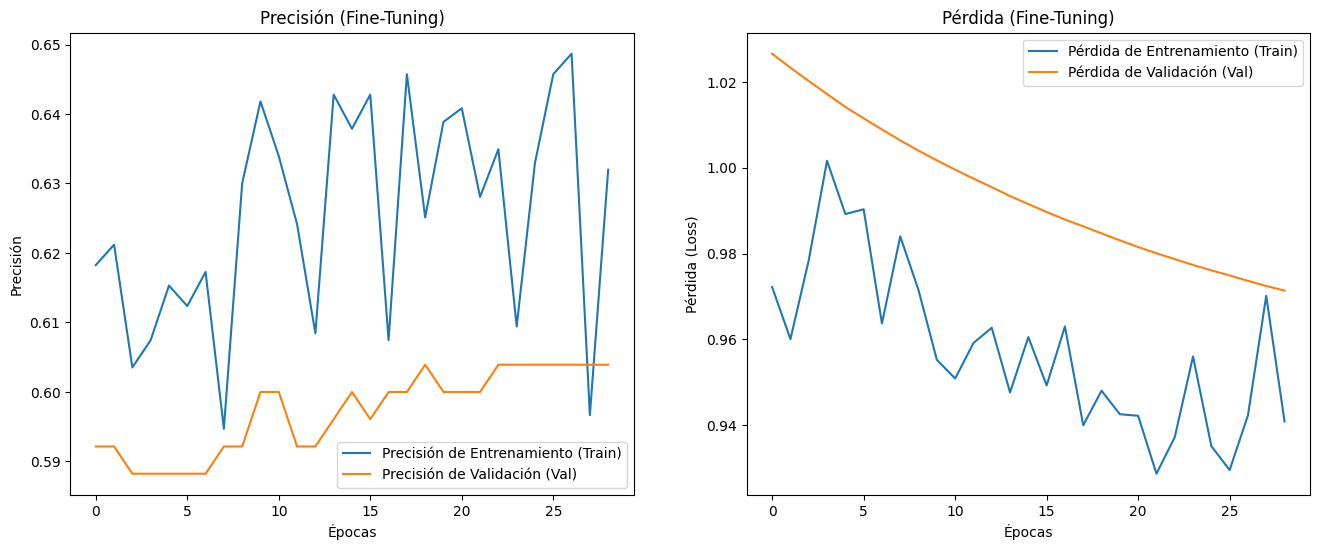

In [42]:
# Graficamos los resultados del Fine tuning.
acc = history_ft.history['accuracy']
val_acc = history_ft.history['val_accuracy']
loss = history_ft.history['loss']
val_loss = history_ft.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión de Entrenamiento (Train)')
plt.plot(epochs_range, val_acc, label='Precisión de Validación (Val)')
plt.legend(loc='lower right')
plt.title('Precisión (Fine-Tuning)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida de Entrenamiento (Train)')
plt.plot(epochs_range, val_loss, label='Pérdida de Validación (Val)')
plt.legend(loc='upper right')
plt.title('Pérdida (Fine-Tuning)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Loss)')

plt.show()

In [44]:
# Continuamos el fine tunning.
wandb.init(
    project="Plant-Pathology-CNN",
    name="VGG16-FineTuning-Ronda2",
    config=config_ft,
    reinit=True)

history_ft_ronda_2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=60,
    callbacks=callbacks_ft)
wandb.finish()

Epoch 1/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 874ms/step - accuracy: 0.6487 - loss: 0.9316
Epoch 1: val_accuracy did not improve from 0.60392
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.6483 - loss: 0.9316 - val_accuracy: 0.6039 - val_loss: 0.9832
Epoch 2/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 847ms/step - accuracy: 0.6257 - loss: 0.9601
Epoch 2: val_accuracy did not improve from 0.60392
32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 988ms/step - accuracy: 0.6260 - loss: 0.9594 - val_accuracy: 0.6000 - val_loss: 0.9817
Epoch 3/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.6293 - loss: 0.9264
Epoch 3: val_accuracy did not improve from 0.60392
32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 960ms/step - accuracy: 0.6293 - loss: 0.9273 - val_accuracy: 0.6000 - val_loss: 0.9802
Epoch 4/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.6151 - loss: 0.9583
Epoch 4: val_accuracy did not improve from 0.60392
32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 976ms/step - accuracy: 0.6158 - loss: 0.9576 - val_accuracy: 0.6039 - 

epoch/accuracy,▅▆▃▆▂▁█▄▇▇▅
epoch/epoch,▁▂▂▃▄▅▅▆▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,▄▅█▄▇▇▄▄▁▄▂
epoch/val_accuracy,█▁▁████████
epoch/val_loss,█▇▆▆▅▄▄▃▂▂▁
epoch/accuracy,0.63494
epoch/epoch,10
epoch/learning_rate,0.0
epoch/loss,0.91895
epoch/val_accuracy,0.60392


## Evaluación final.

In [46]:
# Cargamos el modelo.
FINAL_MODEL_PATH = "final_model_vgg_ft.keras"
final_model = load_model(FINAL_MODEL_PATH)

In [47]:
test_dataset.reset()

print("Los resultados: ")
results = final_model.evaluate(test_dataset)

print("\n" + "---" * 10)
print("Resultados finales")
print(f"Loss en Test:   {results[0]:.4f}")
print(f"Accuracy en Test: {results[1]:.4f}")
print("---" * 10)

Los resultados: 
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 702ms/step - accuracy: 0.6426 - loss: 0.9512

------------------------------
Resultados finales
Loss en Test:   0.9501
Accuracy en Test: 0.6380
------------------------------
